## Investigating optimal pulse duration for minimising CME arrival time/speed errors using OMNI backmapped boundary conditions and MOSWOC Cone CME files

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import copy
from datetime import datetime, timedelta
from astropy.time import Time
from scipy.interpolate import interp1d
from scipy.stats import linregress

In [4]:
# Function to convert a date string to a datetime object
def convert_to_datetime(date_str):
    # List of possible date formats
    date_formats = [
        '%Y-%m-%d %H:%M:%S',
        '%Y/%m/%d %H%M',
        '%Y/%m/%d %H%M(%S)',
        '%Y/%m/%d %H%M(S)',
        '%Y/%m/%d %H:%M',
        '%Y/%m/%d %H:%M:%S',
        '%Y/%m/%d %H:%M(S)',
        '%d/%m/%Y %H:%M'
    ]
    for date_format in date_formats:
        try:
            return datetime.strptime(date_str, date_format)
        except ValueError:
            continue
    # If no format matches, return None
    return None
    
# Function to convert Time_Error from string to timedelta
def convert_to_timedelta(time_str):
    try:
        return pd.to_timedelta(time_str)
    except ValueError:
        return None

In [5]:
def plot_spread_bands(ax, x, median, 
                      q1=None, q3=None,
                      d1=None, d9=None,
                      vmin=None, vmax=None,
                      cmap='cool'):
    """
    Plot spread bands (range + IQR) with median and optional mean.

    Args:
        ax      : matplotlib axis
        x       : x-axis values (e.g. pulse durations)
        median  : median values
        q1, q3  : first and third quartiles (IQR)
        d1, d9 : first and ninth deciles (IDR)
        vmin, vmax : min and max values (full range)
        cmap    : matplotlib colormap name
    """ 

    # Count how many bands we actually have
    n_bands = 3
    norm = mpl.colors.Normalize(vmin=0, vmax=max(n_bands, 1))
    band_index = 0

    # --- RANGE (widest band) ---
    if vmin is not None and vmax is not None:
        rgba = copy.copy(mpl.cm.get_cmap(cmap)(norm(band_index)))
        ax.fill_between(
            x, vmin, vmax,
            color=rgba,
            alpha=0.5,
            label='Range',
            zorder=0
        )
        band_index += 1

    # --- IDR ---
    if d1 is not None and d9 is not None:
        rgba = copy.copy(mpl.cm.get_cmap(cmap)(norm(band_index)))
        ax.fill_between(
            x, d1, d9,
            color=rgba,
            alpha=0.9,
            label='IDR',
            zorder=1
        )
        band_index += 1

    # --- IQR ---
    if q1 is not None and q3 is not None:
        rgba = copy.copy(mpl.cm.get_cmap(cmap)(norm(band_index)))
        ax.fill_between(
            x, q1, q3,
            color=rgba,
            alpha=0.9,
            label='IQR',
            zorder=2
        )
        band_index += 1

    # --- MEDIAN ---
    ax.plot(
        x, median,
        color='tab:olive',
        label='Median',
        marker='.',
        zorder=3,
        linewidth=2)

    # Index where median is closest to zero using interpolation to avoid using only the sampled pulse duration
    f = interp1d(x, median, kind='cubic')
    x_fine = np.linspace(x.min(), x.max(), 500)
    y_fine = f(x_fine)

    best_pulse = x_fine[np.argmin(np.abs(y_fine))]

    # Add line at zero error
    ax.axhline(y=0.0, color='k', linestyle='--',linewidth=1)

    # Add vertical line at optimal pulse duration
    ax.axvline(
        best_pulse,
        color='red',
        linestyle='--',
        linewidth=1,
        label=f'Best (≈0 error): {best_pulse:.1f} h')

    return ax

In [6]:
def plot_v_error_boxplot(
    ax,
    df,
    v_cme,
    ylabel,
    title,
    cmap_name="viridis"):
    """
    Boxplot of CME error vs v_cme with IQR-based colouring.
    
    Parameters
    ----------
    ax : matplotlib axis
    df : pandas DataFrame (CME x pulse durations or similar, already transposed)
    v_cme : array-like (CME speeds, same length as df rows/columns after transpose)
    ylabel : str
    title : str
    cmap_name : str
    """

    # ---- prepare long-form data ----
    df_T = df.T.copy()
    df_T["v_cme"] = v_cme.values

    df_melted = df_T.melt(
        id_vars="v_cme",
        var_name="PulseDuration",
        value_name="Error"
    )

    # ---- IQR per CME speed ----
    spread = (
        df_melted.groupby("v_cme")["Error"]
        .apply(lambda x: np.percentile(x, 75) - np.percentile(x, 25))
    )

    norm = mcolors.Normalize(vmin=spread.min(), vmax=spread.max())
    cmap = cm.get_cmap(cmap_name)

    palette = {str(v): cmap(norm(spread[v])) for v in spread.index}

    # ---- plot ----
    sns.boxplot(
        x="v_cme",
        y="Error",
        data=df_melted,
        order=sorted(spread.index),
        palette=palette,
        ax=ax,
        flierprops=dict(
            marker='D',
            markersize=4,
            markerfacecolor='black',
            markeredgecolor='black',
            alpha=0.6
        )
    )

    ax.axhline(0.0, color='r', linestyle='--')

    ax.set_xlabel("V_cme (km/s)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    ax.tick_params(axis='x', labelsize=11)
    ax.tick_params(axis='y', labelsize=11)

    # colorbar
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = ax.figure.colorbar(sm, ax=ax, pad=0.01)
    cbar.set_label("IQR of Error")

    return df_melted, spread

In [7]:
def plot_w_error_boxplot(
    ax,
    df,
    ang_width,
    ylabel,
    title,
    cmap_name="viridis"):
    """
    Boxplot of CME error vs v_cme with IQR-based colouring.
    
    Parameters
    ----------
    ax : matplotlib axis
    df : pandas DataFrame (CME x pulse durations or similar, already transposed)
    ang_width : array-like (CME angular widths, same length as df rows/columns after transpose)
    ylabel : str
    title : str
    cmap_name : str
    """

    # ---- prepare long-form data ----
    df_T = tt_nabs_error.T.copy()
    df_T["ang_width"] = ang_width.values
    df_T["CME_ID"] = np.arange(len(df_T))

    df_melted = df_T.melt(
        id_vars=["CME_ID", "ang_width"],
        var_name="PulseDuration",
        value_name="Error"
    )
    
    order = (df_T.sort_values("ang_width")["CME_ID"])
    
    # ---- IQR per CME ----
    spread = (
        df_melted.groupby("CME_ID")["Error"]
        .apply(lambda x: np.percentile(x, 75) - np.percentile(x, 25)))

    norm = mcolors.Normalize(vmin=spread.min(), vmax=spread.max())
    cmap = cm.get_cmap("viridis")

    palette = {cme: cmap(norm(spread[cme])) for cme in spread.index}
    colors = [cmap(norm(spread[int(cme)])) for cme in order]

    sns.boxplot(
        x="CME_ID",
        y="Error",
        data=df_melted,
        order=order,
        palette=colors,   # ← list instead of dict
        ax=ax,
        flierprops=dict(
            marker='D',
            markersize=4,
            markerfacecolor='black',
            markeredgecolor='black',
            alpha=0.6
        )
    )

    # Get sorted angular widths (aligned with your order)
    labels = (df_T.sort_values("ang_width")["ang_width"].values)

    # Apply them to the axis
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45)

    ax.axhline(0.0, color='r', linestyle='--')

    ax.set_xlabel("Half angular width (degrees)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    ax.tick_params(axis='x', labelsize=11)
    ax.tick_params(axis='y', labelsize=11)

    # colorbar
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = ax.figure.colorbar(sm, ax=ax, pad=0.01)
    cbar.set_label("IQR of Error")

    return df_melted, spread

# Load in data

In [8]:
# Load dataset
df_tt = pd.read_csv("/Users/dven/repos/CME_pulse_duration/huxt/data/output/cme_transit_time.csv",header=None)
df_av = pd.read_csv("/Users/dven/repos/CME_pulse_duration/huxt/data/output/cme_arrival_speed.csv",header=None)
crlist = pd.read_csv("/Users/dven/repos/CME_pulse_duration/huxt/data/input/(I)CMEs.csv")

In [9]:
# Convert date columns to datetime objects using datetime library
date_columns = ['Time_21.5','Disturbance_Time']
for column in date_columns:
    crlist[column] = crlist[column].apply(lambda x: convert_to_datetime(x) if isinstance(x, str) else None)

# Add observed values to the arrival speed dataframe
new_rows = ['V_max', 'V_max_smooth']

rows=[]

for row in new_rows:
    data = [row] + crlist[row].tolist()
    rows.append(data)

combined_df = pd.DataFrame(rows)

df_tt = pd.concat([combined_df, df_tt], ignore_index=True)
df_av = pd.concat([combined_df, df_av], ignore_index=True)

In [10]:
# Rename first column by rounding its values to 1 decimal place (excluding the first six rows which are CME parameters)
df_tt.iloc[6:, 0] = df_tt.iloc[6:, 0].str.extract(r'([\d\.]+)').astype(float).round(1)
df_av.iloc[6:, 0] = df_av.iloc[6:, 0].str.extract(r'([\d\.]+)').astype(float).round(1)

# Find all columns that have any NaN in either dataframe
cols_with_nan = df_tt.columns[df_tt.isna().any() | df_av.isna().any()]

# Drop those columns from both dataframes
df_tt = df_tt.drop(columns=cols_with_nan)
df_av = df_av.drop(columns=cols_with_nan)

In [11]:
df_av.info()
df_tt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       45 non-null     object 
 1   2       45 non-null     float64
 2   5       45 non-null     float64
 3   6       45 non-null     float64
 4   7       45 non-null     float64
 5   8       45 non-null     float64
 6   10      45 non-null     float64
 7   13      45 non-null     float64
 8   14      45 non-null     float64
 9   15      45 non-null     float64
 10  18      45 non-null     float64
 11  20      45 non-null     float64
 12  21      45 non-null     float64
 13  25      45 non-null     float64
 14  30      45 non-null     float64
 15  31      45 non-null     float64
 16  32      45 non-null     float64
dtypes: float64(16), object(1)
memory usage: 6.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype  
-

# Error Calculations

In [12]:
# Extract pulse duration values (rows), CME transit time data, and CME parameters

tt = df_tt.iloc[6:,1:] # transit time fixed duration
ang_width = df_tt.iloc[2,1:] # angular width of CMEs
v_cme = df_tt.iloc[3,1:] # velocity of CMEs at 21.5 solRads
tt_obs = df_tt.iloc[4,1:] # observed transit time
tt_sph = df_tt.iloc[5,1:] # transit time spheroidal cone cme

pulse_durations = df_tt.iloc[6:, 0] # range of pulse durations
pulse_durations = pulse_durations.astype(float)

In [13]:
print(np.average(tt_obs))
print(np.average(tt))

2.875
2.8088920537082913


In [14]:
# Calculate errors in transit time
tt_error = (tt - tt_obs).abs()
tt_nabs_error = (tt - tt_obs)
tt_sph_error = (tt_sph - tt_obs).abs()
tt_sph_nabs_error = (tt_sph - tt_obs)

tt_error = tt_error.apply(pd.to_numeric, errors='coerce')
tt_nabs_error = tt_nabs_error.apply(pd.to_numeric, errors='coerce')
tt_sph_error = tt_sph_error.apply(pd.to_numeric, errors='coerce')
tt_sph_nabs_error = tt_sph_nabs_error.apply(pd.to_numeric, errors='coerce')

In [15]:
# Finding measures of errors
tt_mae = tt_nabs_error.mean(axis=1)
tt_median = tt_nabs_error.median(axis=1)
tt_q1 = tt_nabs_error.quantile(q=0.25,axis=1)
tt_q3 = tt_nabs_error.quantile(q=0.75,axis=1)
tt_d1 = tt_nabs_error.quantile(q=0.1,axis=1)
tt_d9 = tt_nabs_error.quantile(q=0.9,axis=1)
tt_min = tt_nabs_error.min(axis=1)
tt_max = tt_nabs_error.max(axis=1)

tt_median_sph = tt_sph_error.median()
tt_median_sph_nabs = tt_sph_error.median()

In [16]:
# Extract pulse duration values (rows), CME arrival speed data, and CME parameters

av = df_av.iloc[6:,1:] # arrival speed fixed duration
av_obs = df_av.iloc[0,1:] # observed arrival speed using 1h maximum speed
av_obs_smth = df_av.iloc[1,1:] # observed arrival speed using 8h smoothed maximum speed
av_sph = df_av.iloc[5,1:] # arrival speed spheroidal cone cme

pulse_durations = df_av.iloc[6:, 0] # range of pulse durations
pulse_durations = pulse_durations.astype(float)

In [17]:
print(np.average(av_obs))
print(np.average(av_obs_smth))
print(np.average(av_sph))

521.6875
501.9375
548.7828330774769


In [18]:
# Calculate errors in arrival speed
av_error = (av - av_obs).abs()
av_nabs_error = (av - av_obs)
av_nabs_smth = (av - av_obs_smth)
av_sph_error = (av_sph - av_obs)
av_sph_smth = (av_sph - av_obs_smth)

av_error = av_error.apply(pd.to_numeric, errors='coerce')
av_nabs_error = av_nabs_error.apply(pd.to_numeric, errors='coerce')
av_nabs_smth = av_nabs_smth.apply(pd.to_numeric, errors='coerce')
av_sph_error = av_sph_error.apply(pd.to_numeric, errors='coerce')
av_sph_smth = av_sph_smth.apply(pd.to_numeric, errors='coerce')

In [19]:
# Finding measures of errors
av_mae = av_nabs_error.mean(axis=1)
av_median = av_nabs_error.median(axis=1)
av_median_smth = av_nabs_smth.median(axis=1)
av_q1 = av_nabs_error.quantile(q=0.25,axis=1)
av_q3 = av_nabs_error.quantile(q=0.75,axis=1)
av_d1 = av_nabs_error.quantile(q=0.1,axis=1)
av_d9 = av_nabs_error.quantile(q=0.9,axis=1)
av_min = av_nabs_error.min(axis=1)
av_max = av_nabs_error.max(axis=1)

av_median_sph = av_sph_error.median()
av_median_sph_smth = av_sph_smth.median()

In [20]:
print(av_median)

6     -16.678342
7     -18.438245
8       3.645964
9      -2.117111
10      8.772529
11     26.893583
12     43.686750
13     52.466714
14     61.240807
15     73.130928
16     84.930137
17     97.164800
18    108.628425
19    120.593554
20    131.306873
21    143.111007
22    154.242023
23    165.757515
24    182.075212
25    199.266062
26    209.042363
27    218.815406
28    226.192587
29    235.263762
30    243.031608
31    252.084371
32    259.596968
33    267.231424
34    273.665501
35    282.489555
36    288.985291
37    296.683981
38    302.020546
39    308.346127
40    319.977308
41    329.884222
42    341.205408
43    351.536827
44    360.373185
dtype: float64


# Error distribution for each pulse duration

/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_22225/3921336422.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  rgba = copy.copy(mpl.cm.get_cmap(cmap)(norm(band_index)))
/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_22225/3921336422.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  rgba = copy.copy(mpl.cm.get_cmap(cmap)(norm(band_index)))
/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_22225/3921336422.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()``

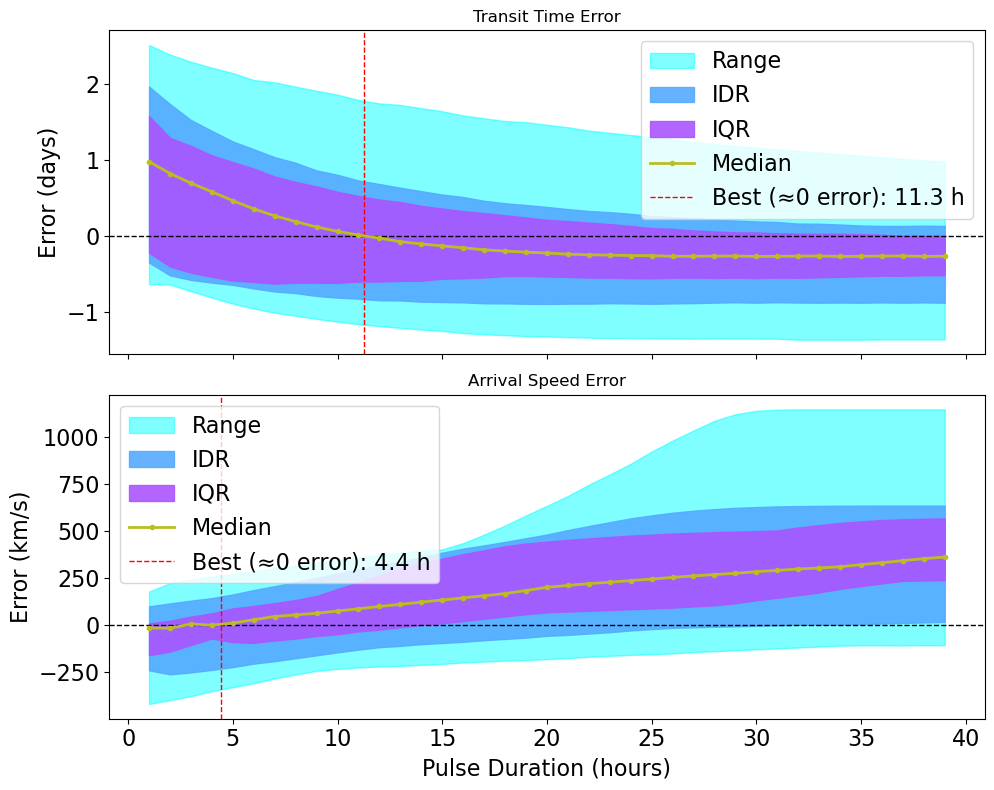

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1, ax2 = axes

# --- Top plot: Transit Time Error ---
plot_spread_bands(
    ax1,
    pulse_durations,
    median=tt_median,
    q1=tt_q1,
    q3=tt_q3,
    d1=tt_d1,
    d9=tt_d9,
    vmin=tt_min,
    vmax=tt_max
)

ax1.set_ylabel('Error (days)')
ax1.set_title('Transit Time Error')
ax1.legend()

# --- Bottom plot: Arrival Speed Error ---
plot_spread_bands(
    ax2,
    pulse_durations,
    median=av_median,
    q1=av_q1,
    q3=av_q3,
    d1=av_d1,
    d9=av_d9,
    vmin=av_min,
    vmax=av_max
)

ax2.set_xlabel('Pulse Duration (hours)')
ax2.set_ylabel('Error (km/s)')
ax2.set_title('Arrival Speed Error')
ax2.legend()

fig.tight_layout()

filename = "/Users/dven/repos/CME_pulse_duration/huxt/figures/analysis/Error_bands.pdf"
fig.savefig(filename, format="pdf", bbox_inches="tight")

# Error distribution for each CME arranged by V, ang_width

/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_22225/540503218.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_22225/540503218.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_22225/540503218.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T

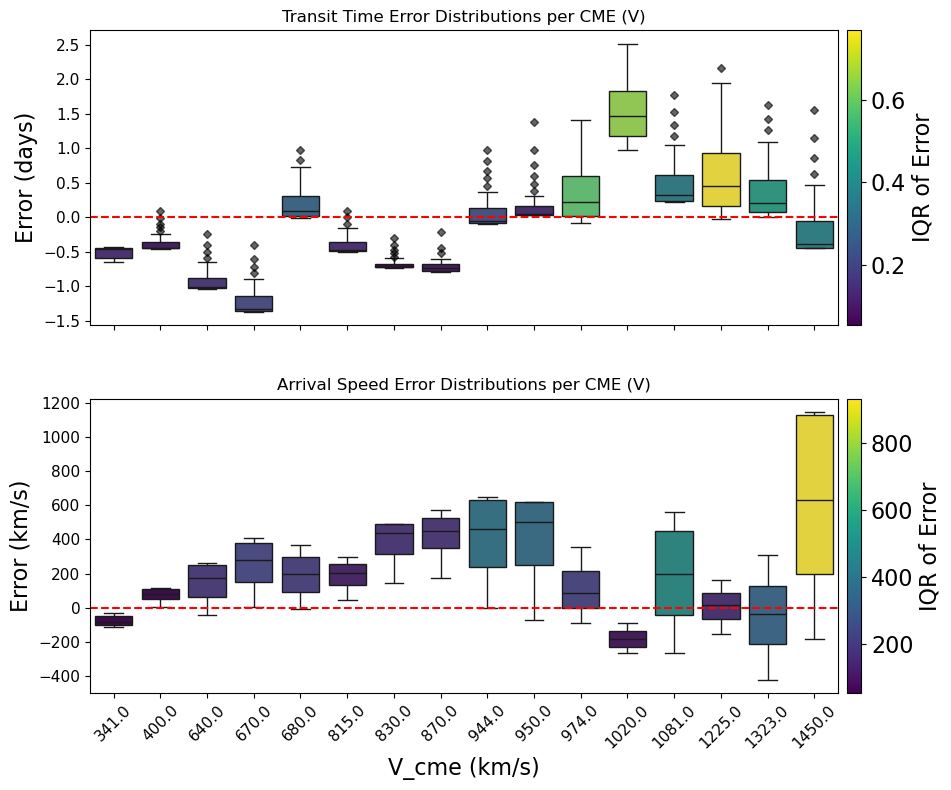

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

df_melted_tt, spread_tt = plot_v_error_boxplot(
    axes[0],
    tt_nabs_error,
    v_cme,
    ylabel="Error (days)",
    title="Transit Time Error Distributions per CME (V)"
)

df_melted_av, spread_av = plot_v_error_boxplot(
    axes[1],
    av_nabs_error,
    v_cme,
    ylabel="Error (km/s)",
    title="Arrival Speed Error Distributions per CME (V)"
)

axes[1].tick_params(axis='x', labelrotation=45)

fig.tight_layout()
fig.subplots_adjust(hspace=0.25)

fig.savefig(
    "/Users/dven/repos/CME_pulse_duration/huxt/figures/analysis/error_vs_vcme.pdf",
    bbox_inches="tight"
)

/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_22225/3333257964.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")
/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_22225/3333257964.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_22225/3333257964.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")
/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000g

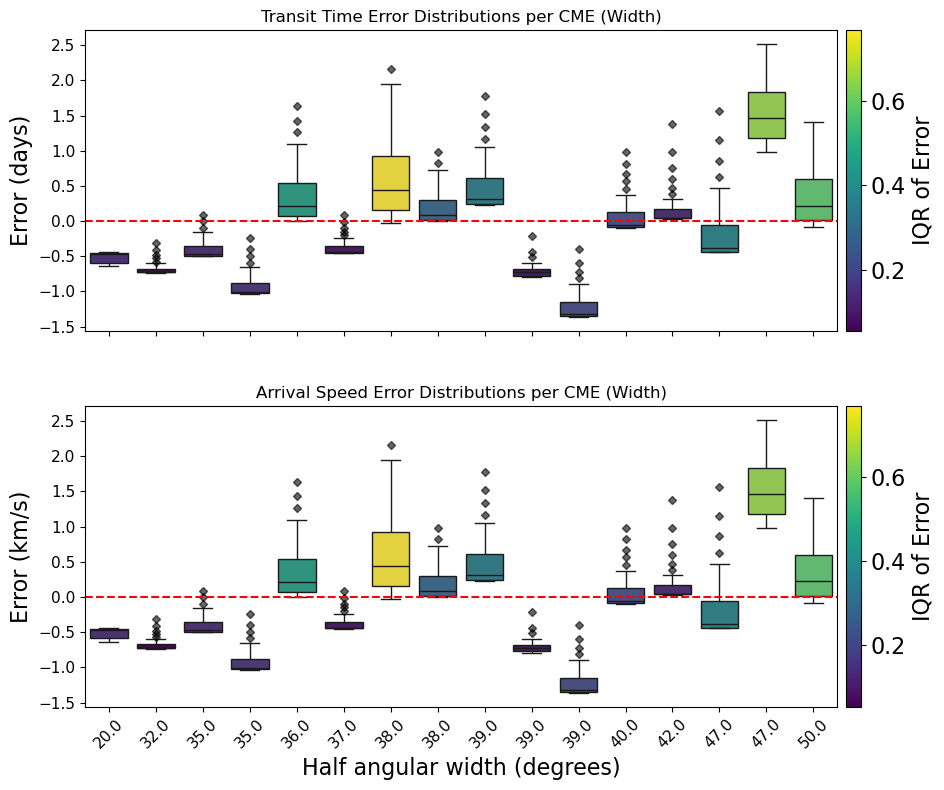

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

df_melted_tt, spread_tt = plot_w_error_boxplot(
    axes[0],
    tt_nabs_error,
    ang_width,
    ylabel="Error (days)",
    title="Transit Time Error Distributions per CME (Width)"
)

df_melted_av, spread_av = plot_w_error_boxplot(
    axes[1],
    av_nabs_error,
    ang_width,
    ylabel="Error (km/s)",
    title="Arrival Speed Error Distributions per CME (Width)"
)

axes[1].tick_params(axis='x', labelrotation=45)

fig.tight_layout()
fig.subplots_adjust(hspace=0.25)

fig.savefig(
    "/Users/dven/repos/CME_pulse_duration/huxt/figures/analysis/error_vs_angwidth.pdf",
    bbox_inches="tight"
)

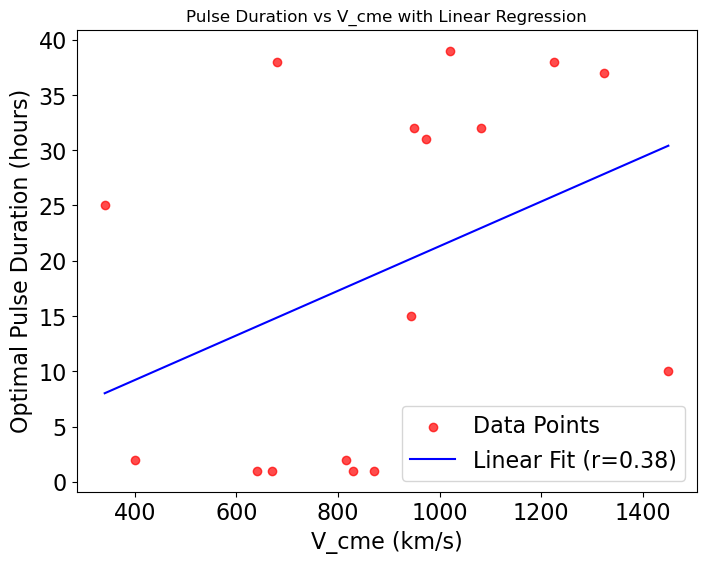

Linear Regression Equation: y = 0.0202 * x + 1.1234
R-squared: 0.1437
P-value: 0.1476


In [24]:
# Ensure v_cme is in a 1D format
v_cme_values = v_cme.values.flatten()
v_cme_values = v_cme_values.astype(float)

# Find the row index of the minimum value for each column in tt_error
min_indices = tt_error.idxmin(axis=0)  # Get row index of min value for each column

# Step 2: Extract corresponding pulse durations (since pulse_durations is 1D)
pulse_durations_min = pulse_durations.loc[min_indices].values  # Direct lookup

# Step 3: Perform linear regression (pulse duration = y, v_cme = x)
slope, intercept, r_value, p_value, std_err = linregress(v_cme_values, pulse_durations_min)

# Generate fitted line
v_cme_fit = np.linspace(min(v_cme_values), max(v_cme_values), 100)  # Smooth line
pulse_fit = slope * v_cme_fit + intercept  # Compute regression line

# Step 4: Plot scatter and regression line
plt.figure(figsize=(8, 6))
plt.scatter(v_cme_values, pulse_durations_min, color='r', alpha=0.7, label='Data Points')
plt.plot(v_cme_fit, pulse_fit, color='b', linestyle='-', label=f'Linear Fit (r={r_value:.2f})')

# Labels and title
plt.xlabel('V_cme (km/s)')
plt.ylabel('Optimal Pulse Duration (hours)')
plt.title('Pulse Duration vs V_cme with Linear Regression')
plt.legend()

# Save and show plot
plt.savefig('/Users/dven/repos/CME_pulse_duration/huxt/figures/analysis/duration_vcme_regression.pdf', format='pdf')
plt.show()

# Print regression results
print(f"Linear Regression Equation: y = {slope:.4f} * x + {intercept:.4f}")
print(f"R-squared: {r_value**2:.4f}")
print(f"P-value: {p_value:.4g}")

# Both 

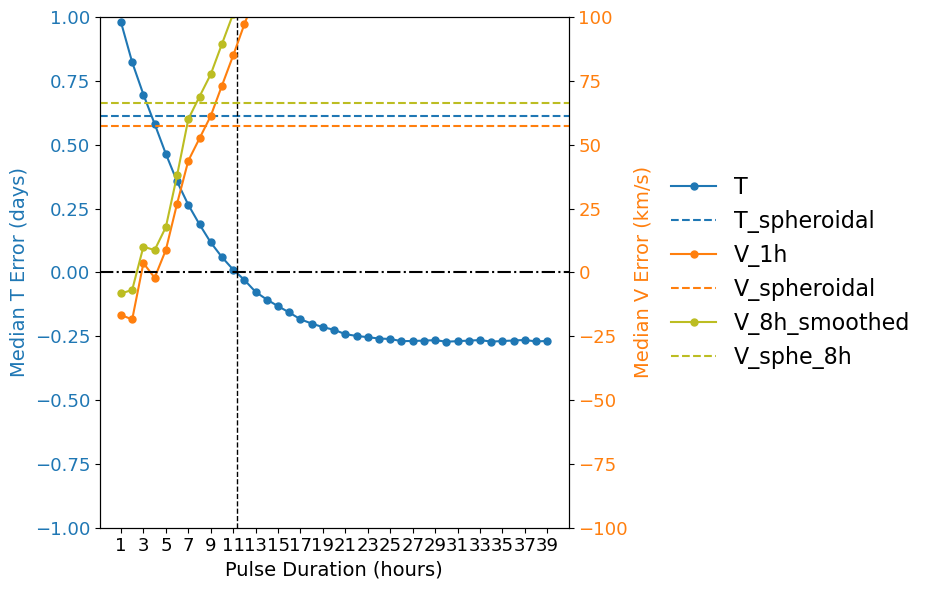

In [27]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Left y-axis: Transit Time Error
color1 = 'tab:blue'
ax1.set_xlabel('Pulse Duration (hours)', fontsize=14)
ax1.set_ylabel('Median T Error (days)', color=color1, fontsize=14)
line1 = ax1.plot(pulse_durations, tt_median, marker='o', markersize=5, linestyle='-', color=color1, label='T')
ax1.axhline(y=tt_median_sph_nabs, color=color1, linestyle='--', label='T_spheroidal')
ax1.tick_params(axis='y', labelcolor=color1, labelsize=13)
ax1.tick_params(axis='x', labelsize=13)
ax1.set_xticks(np.arange(min(pulse_durations), max(pulse_durations) + 1, 2))

# Right y-axis: Arrival Speed Error
ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.set_ylabel('Median V Error (km/s)', color=color2, fontsize=14)
line2 = ax2.plot(pulse_durations, av_median, marker='o', markersize=5, linestyle='-', color=color2, label='V_1h')
ax2.axhline(y=av_median_sph, color=color2, linestyle='--', label='V_spheroidal')
ax2.axhline(y=0.0, color='black', linestyle='-.')
ax2.tick_params(axis='y', labelcolor=color2, labelsize=13)

# Add speed errors calculated using smoothed data
color3 = 'tab:olive'
line3 = ax2.plot(pulse_durations, av_median_smth, marker='o', markersize=5, linestyle='-', color=color3, label='V_8h_smoothed')
ax2.axhline(y=av_median_sph_smth, color=color3, linestyle='--', label='V_sphe_8h')

# Add vertical lines at intersections (or closest match)
ax1.axvline(11.3, color='black', linestyle='--', linewidth=1)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

plt.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='center left',
    bbox_to_anchor=(1.2, 0.5),
    borderaxespad=0,
    frameon=False
)

ax1.set_ylim(-1.0,1.0)
ax2.set_ylim(-100,100)

# Save and show
filename = ("/Users/dven/repos/CME_pulse_duration/huxt/figures/analysis/error_vs_pulse_duration_combined.pdf")
fig.tight_layout()
fig.savefig(filename, format="pdf", bbox_inches="tight")

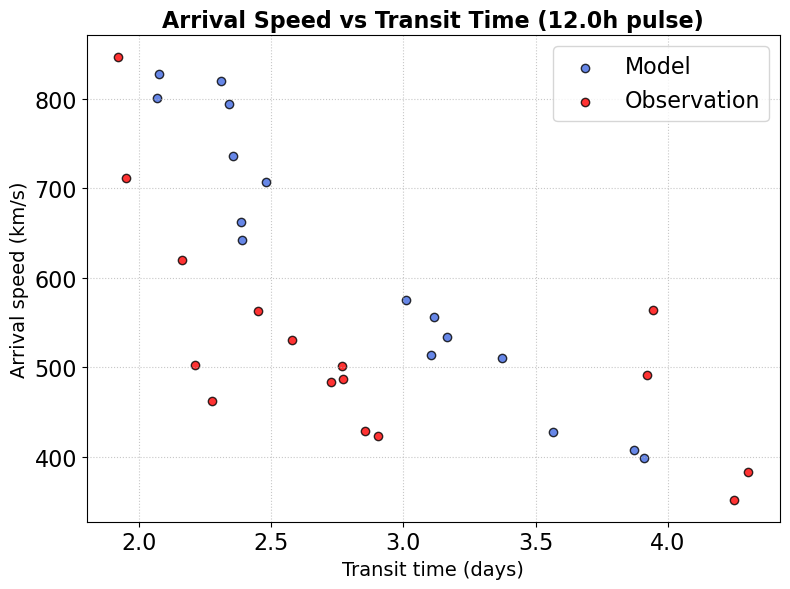

In [28]:
plt.figure(figsize=(8, 6))
plt.scatter(tt.iloc[11, :],av.iloc[11, :],color='royalblue', edgecolor='black', label='Model', alpha=0.8)
plt.scatter(tt_obs,av_obs,color='red', edgecolor='black', label='Observation', alpha=0.8)
plt.xlabel('Transit time (days)', fontsize=14)
plt.ylabel('Arrival speed (km/s)', fontsize=14)
plt.title('Arrival Speed vs Transit Time (12.0h pulse)', fontsize=16, weight='bold')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
filename = ("/Users/dven/repos/CME_pulse_duration/huxt/figures/analysis/tt_av_11.pdf")
plt.savefig(filename, format='pdf', bbox_inches='tight')
plt.show()

In [132]:
print(pulse_durations.iloc[11])

12.0


In [133]:
# Ensure v_cme is in a 1D format
v_cme_values = v_cme.values.flatten()
v_cme_values = v_cme_values.astype(float)

y = 0.0202 * v_cme_values + 1.1234
pulse = np.round(y / 1.0) * 1.0
pulse = np.round(pulse, 2)
print(pulse)

row_map = {v: i for i, v in enumerate(pulse_durations.values)}
row_idx = np.array([row_map[p] for p in pulse])
print(row_idx)

col_idx = np.arange(tt_nabs_error.shape[1])
print(col_idx)

result = pd.Series(
    tt_nabs_error.to_numpy()[row_idx, col_idx]
)
print(result)

[28. 18. 23. 20. 30. 19. 22. 18. 26.  9. 21.  8. 20. 15. 15. 14.]
[27 17 22 19 29 18 21 17 25  8 20  7 19 14 14 13]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
0     0.086530
1    -0.454164
2     0.272536
3     0.041701
4    -0.443192
5    -0.789129
6     1.388233
7    -0.716968
8     0.242248
9    -0.334626
10    0.198330
11   -0.610635
12   -0.061393
13   -1.254442
14    0.181786
15   -0.943730
dtype: float64


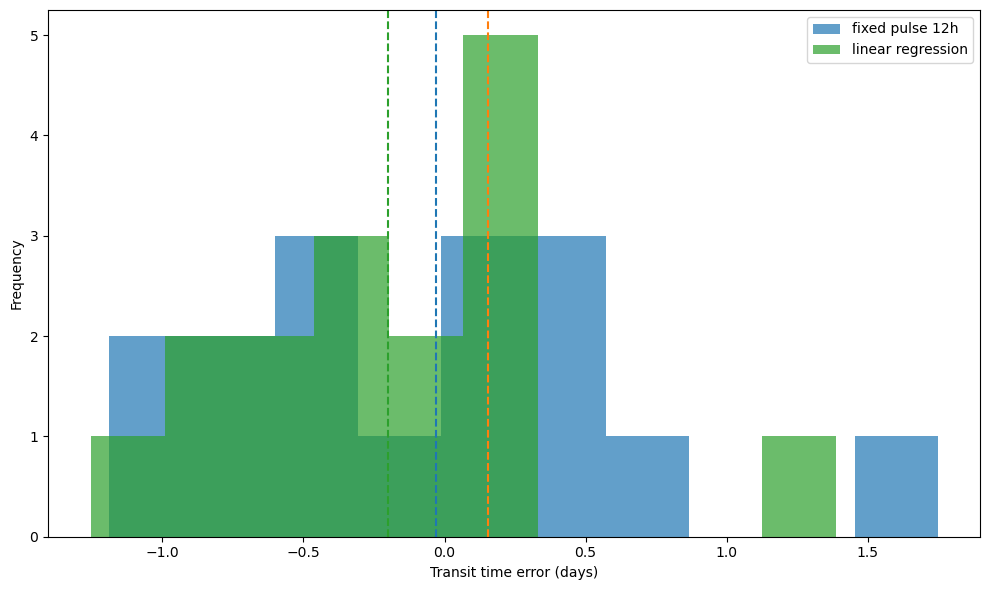

In [134]:
fig, ax = plt.subplots(figsize=(10, 6))

# define colours
c_fixed = "tab:blue"
c_sph = "tab:orange"
c_reg = "tab:green"

# histograms
ax.hist(tt_nabs_error.iloc[11, :], alpha=0.7, color=c_fixed, label='fixed pulse 12h')
#ax.hist(tt_sph_nabs_error, alpha=0.7, color=c_sph, label='spheroidal')
ax.hist(result, alpha=0.7, color=c_reg, label='linear regression')

# medians (same colours)
ax.axvline(np.mean(tt_nabs_error.iloc[11, :]), color=c_fixed, linestyle='--')
ax.axvline(np.mean(tt_sph_nabs_error), color=c_sph, linestyle='--')
ax.axvline(np.mean(result), color=c_reg, linestyle='--')

ax.legend()
ax.set_xlabel("Transit time error (days)")
ax.set_ylabel("Frequency")

filename = ("/Users/dven/repos/CME_pulse_duration/huxt/figures/analysis/pd_selection_comparison.pdf")
fig.tight_layout()
fig.savefig(filename, format="pdf", bbox_inches="tight")

In [135]:
def abs_error():
    fixed = tt_nabs_error.iloc[11, :]
    fixed = fixed.abs()
    mean_fixed = fixed.mean()

    reg = result.abs()
    mean_reg = reg.mean()

    print('Mean absolute error for 12h fixed pulse:', mean_fixed)
    print('Mean absolute error for linear regression-picked pulse;', mean_reg)

abs_error()

Mean absolute error for 12h fixed pulse: 0.6009800509944196
Mean absolute error for linear regression-picked pulse; 0.5012276771359638
